# 06 — Hyperparameter and family multiplicity (multi-seed)

**Purpose:** One place for family importance, within-family HP importance (decomposition and V_m-based), hotspot-specific drivers, and seed aggregation.

**Design:** Load runs once per dataset and `pool_type`, build tidy tables (`metrics_long`, model-level, wide HP tables), aggregate across seeds, then plot from aggregates. Extend `POOL_TYPES` to add `full_pool` when comparing the full candidate pool to the Rashomon subset.


## Imports and path setup


In [15]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import RAW_RESULTS, thesis_output_dirs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.experiment_runner import _get_run_dirs
from analysis.hp_analysis import (
    POOL_TYPE_FULL_POOL,
    POOL_TYPE_RASHOMON,
    aggregate_hp_importance,
    marginal_Vm_by_hp,
    select_pool_indices,
)
from analysis.hp_multiplicity_pipeline import (
    aggregate_decomposition_hp,
    aggregate_family_importance_long,
    aggregate_hotspot_delta,
    hotspot_delta_decomp,
    plot_decomp_hp_bars,
    plot_family_importance_bars,
    plot_hotspot_hp_delta,
    plot_vm_hp_bars,
    run_dataset_all_seeds,
)

RESULTS_DIR = RAW_RESULTS
TABLE_DIR, FIG_DIR = thesis_output_dirs("nb06")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


## Configuration


In [16]:
DATASETS = ["compas", "german", "adult"]
K_EACH = 25
TOP_HP = 10
MIN_HH_OBS = 5

# Candidate pools to analyse (Rashomon only by default; append POOL_TYPE_FULL_POOL for full pool).
POOL_TYPES = [POOL_TYPE_RASHOMON]

# Optional: inspect one seed in addition to aggregate views (set to None to skip).
ILLUSTRATE_SEED = None


## Multi-seed pipeline: per-seed tables

For each dataset and `pool_type`, all seeds: family + HP decomposition on `all` / `HH` / `non_HH`, V_m-based HP importance on the same subsets, and a model-level table (`V_m`, `V_m_HH`, `V_m_nonHH`, validation Brier).


In [17]:
def run_all_pools_for_dataset(ds: str, pool_types: list) -> dict:
    parts = []
    for pt in pool_types:
        ds_dir = RESULTS_DIR / ds
        if not ds_dir.is_dir() or not _get_run_dirs(ds_dir):
            continue
        out = run_dataset_all_seeds(
            ds_dir,
            ds,
            pool_type=pt,
            rashomon_k_each=K_EACH,
            min_hh_obs=MIN_HH_OBS,
        )
        parts.append(out)
    if not parts:
        return {
            "models": pd.DataFrame(),
            "metrics_long": pd.DataFrame(),
            "decomp_hp_wide": pd.DataFrame(),
            "vm_hp_wide": pd.DataFrame(),
        }
    return {k: pd.concat([p[k] for p in parts], ignore_index=True) for k in parts[0]}


all_models, all_long, all_decomp, all_vm = [], [], [], []
for ds in DATASETS:
    out = run_all_pools_for_dataset(ds, POOL_TYPES)
    if not out["models"].empty:
        all_models.append(out["models"])
    if not out["metrics_long"].empty:
        all_long.append(out["metrics_long"])
    if not out["decomp_hp_wide"].empty:
        all_decomp.append(out["decomp_hp_wide"])
    if not out["vm_hp_wide"].empty:
        all_vm.append(out["vm_hp_wide"])

df_models = pd.concat(all_models, ignore_index=True) if all_models else pd.DataFrame()
df_metrics_long = pd.concat(all_long, ignore_index=True) if all_long else pd.DataFrame()
df_decomp_hp = pd.concat(all_decomp, ignore_index=True) if all_decomp else pd.DataFrame()
df_vm_hp = pd.concat(all_vm, ignore_index=True) if all_vm else pd.DataFrame()

for ds in DATASETS:
    for name, df in (
        ("models", df_models),
        ("metrics_long", df_metrics_long),
        ("decomp_hp_per_seed", df_decomp_hp),
        ("vm_hp_per_seed", df_vm_hp),
    ):
        sub = df[df["dataset"] == ds] if not df.empty and "dataset" in df.columns else df
        if sub is not None and not sub.empty:
            sub.to_csv(TABLE_DIR / f"{name}_{ds}.csv", index=False)

    # Backwards-compatible filenames: V_m HP on test-set slice ``subset == all`` only.
    if not df_vm_hp.empty:
        legacy = df_vm_hp[(df_vm_hp["dataset"] == ds) & (df_vm_hp["subset"] == "all")]
        if not legacy.empty:
            legacy.to_csv(TABLE_DIR / f"hp_importance_per_seed_{ds}.csv", index=False)

print("Rows:", {k: len(v) for k, v in [
    ("models", df_models),
    ("metrics_long", df_metrics_long),
    ("decomp_hp", df_decomp_hp),
    ("vm_hp", df_vm_hp),
]})


Rows: {'models': 3750, 'metrics_long': 3124, 'decomp_hp': 1479, 'vm_hp': 1479}


## Optional: single-seed illustration


In [18]:
if ILLUSTRATE_SEED is not None and not df_vm_hp.empty:
    show = df_vm_hp[df_vm_hp["seed"] == ILLUSTRATE_SEED].sort_values(
        ["dataset", "family", "ratio_of_sums"], ascending=[True, True, False]
    )
    display(show.head(40))
else:
    print("Set ILLUSTRATE_SEED to an integer to preview one seed (optional).")


Set ILLUSTRATE_SEED to an integer to preview one seed (optional).


## Aggregation across seeds


In [19]:
df_fam_agg = aggregate_family_importance_long(df_metrics_long)
df_decomp_agg = aggregate_decomposition_hp(df_decomp_hp)
df_vm_all = df_vm_hp[df_vm_hp["subset"] == "all"].copy() if not df_vm_hp.empty else pd.DataFrame()
df_vm_agg = aggregate_hp_importance(df_vm_all)

for ds in DATASETS:
    if not df_fam_agg.empty:
        sub_f = df_fam_agg[df_fam_agg["dataset"] == ds]
        if not sub_f.empty:
            sub_f.to_csv(TABLE_DIR / f"family_importance_agg_{ds}.csv", index=False)
    if not df_decomp_agg.empty:
        sub = df_decomp_agg[df_decomp_agg["dataset"] == ds]
        if not sub.empty:
            sub.to_csv(TABLE_DIR / f"decomp_hp_importance_agg_{ds}.csv", index=False)
    if not df_vm_agg.empty:
        sub = df_vm_agg[df_vm_agg["dataset"] == ds]
        if not sub.empty:
            sub.to_csv(TABLE_DIR / f"hp_importance_agg_{ds}.csv", index=False)

delta_seed = hotspot_delta_decomp(df_decomp_hp)
df_delta_agg = aggregate_hotspot_delta(delta_seed)
if not df_delta_agg.empty:
    df_delta_agg.to_csv(TABLE_DIR / "decomp_hp_hotspot_delta_agg.csv", index=False)


## Family importance (mean ± std over seeds)


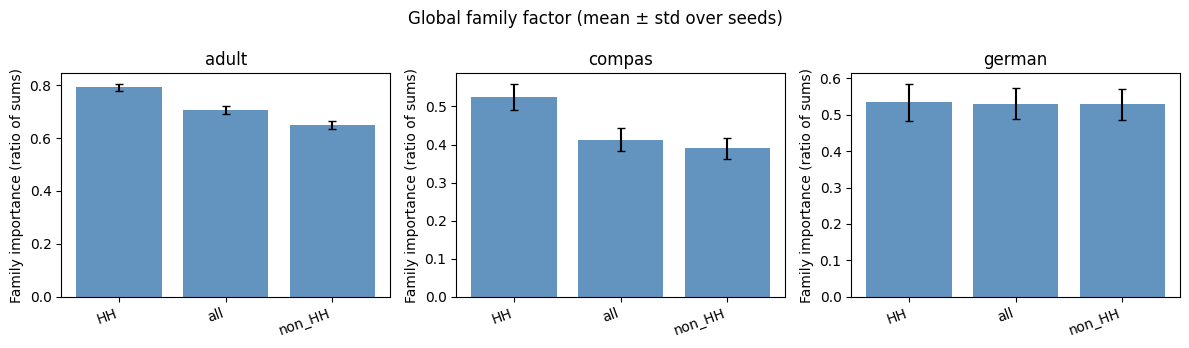

In [20]:
if not df_fam_agg.empty:
    plot_family_importance_bars(df_fam_agg, fig_path=FIG_DIR / "family_importance_agg.pdf")
else:
    print("No family-importance rows.")


## V_m-based within-family HP importance (subset = all)


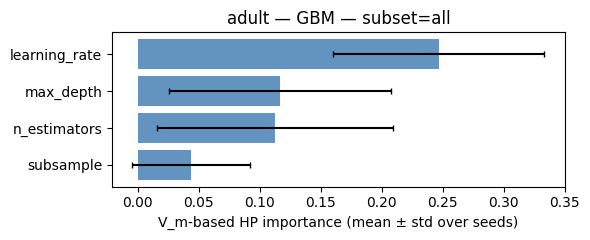

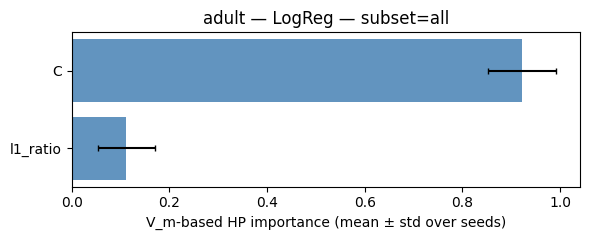

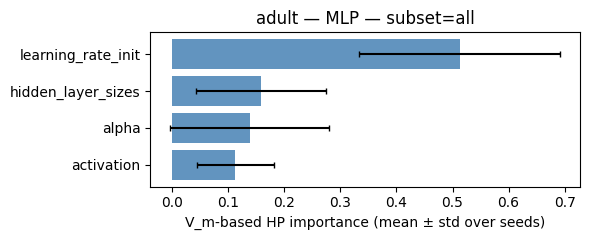

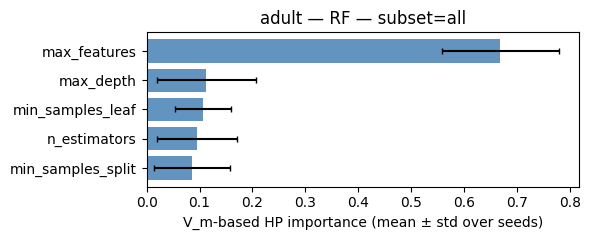

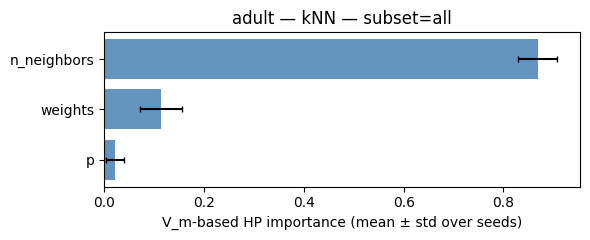

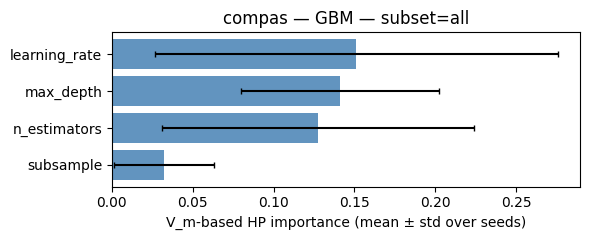

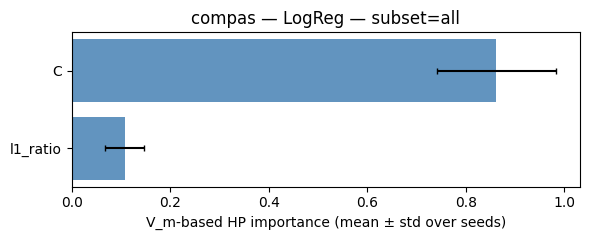

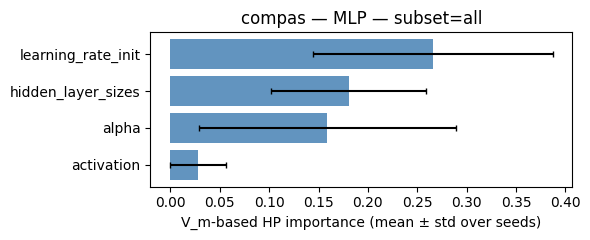

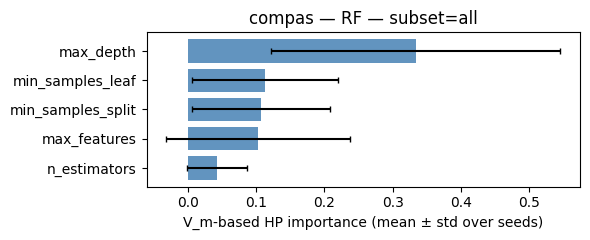

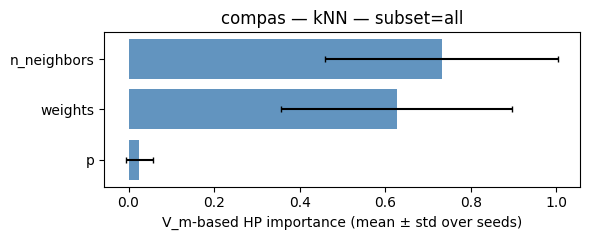

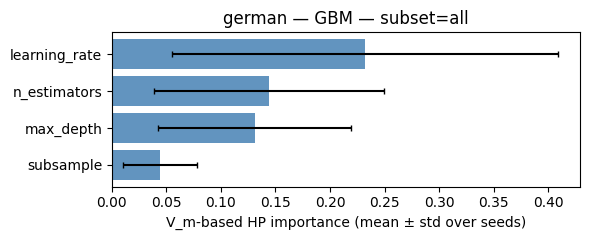

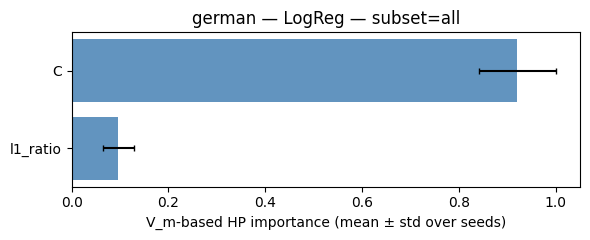

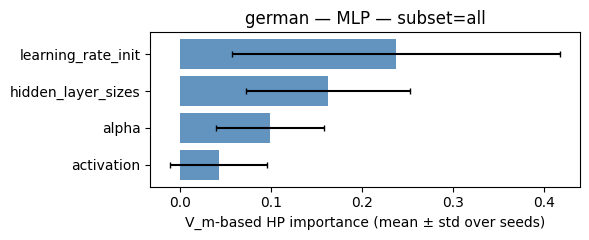

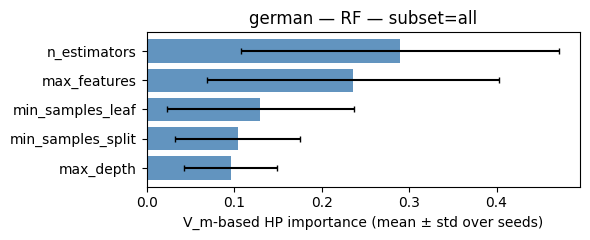

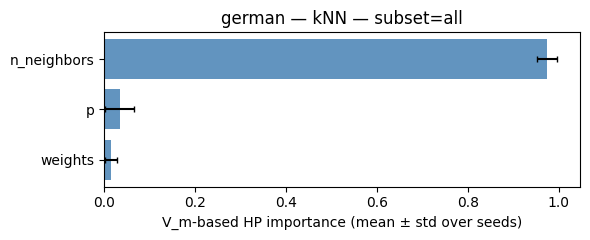

In [21]:
if not df_vm_agg.empty:
    for (ds, fam), grp in df_vm_agg.groupby(["dataset", "family"]):
        plot_vm_hp_bars(
            df_vm_agg,
            dataset=ds,
            family=fam,
            subset="all",
            pool_type=POOL_TYPE_RASHOMON if POOL_TYPE_RASHOMON in POOL_TYPES else None,
            top_n=TOP_HP,
            fig_path=FIG_DIR / f"hp_importance_bar_{ds}_{fam}.pdf",
        )
else:
    print("No V_m HP importance aggregates.")


## Rank stability (V_m-based, top HPs per family)


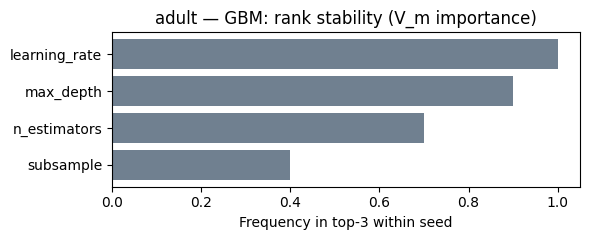

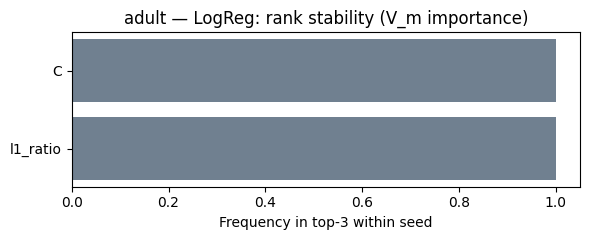

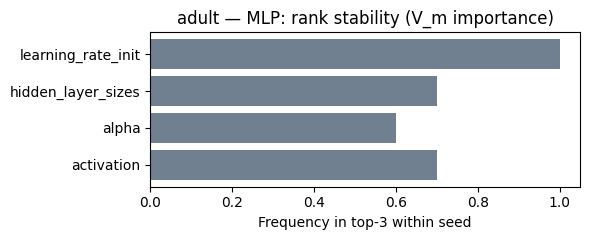

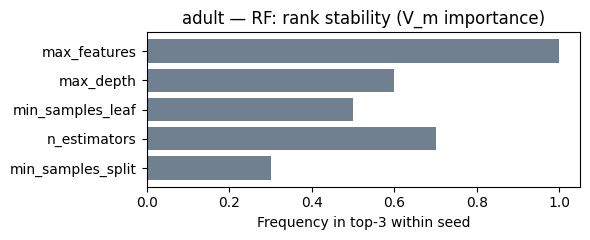

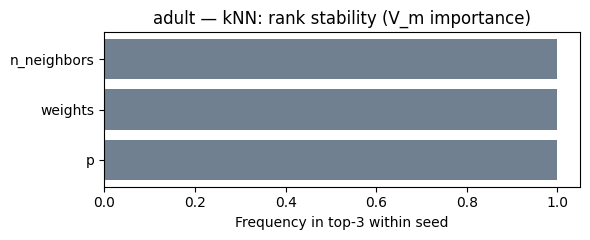

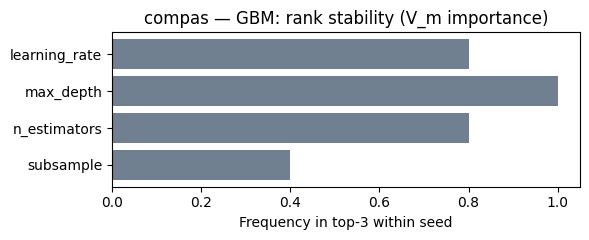

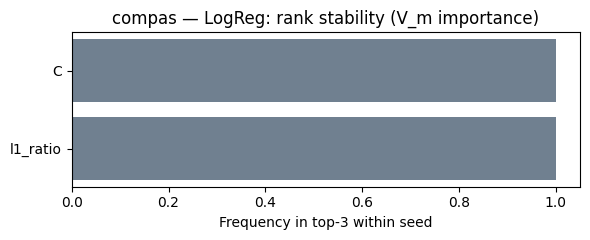

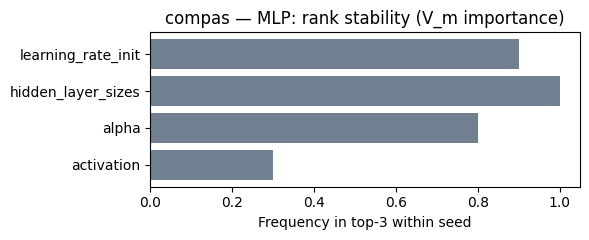

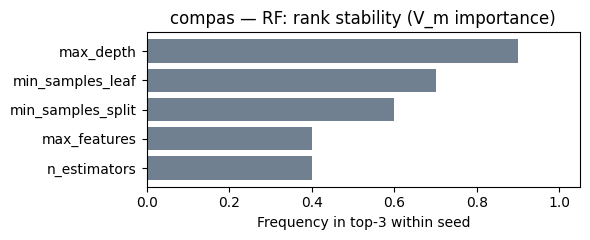

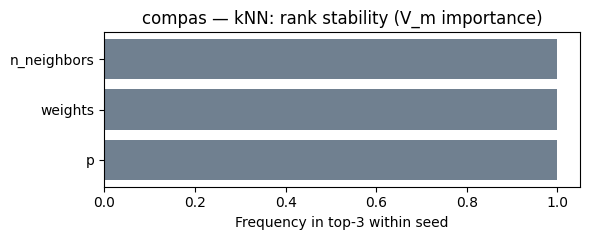

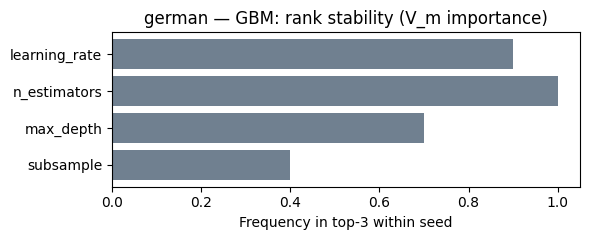

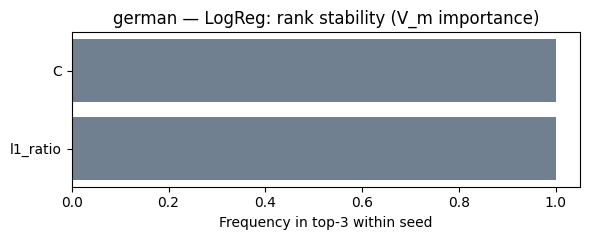

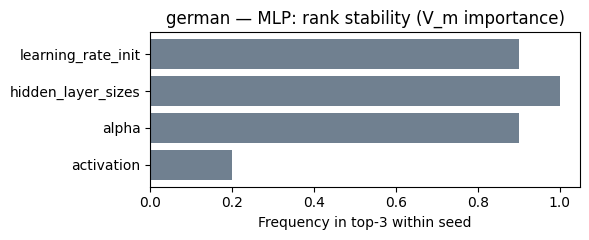

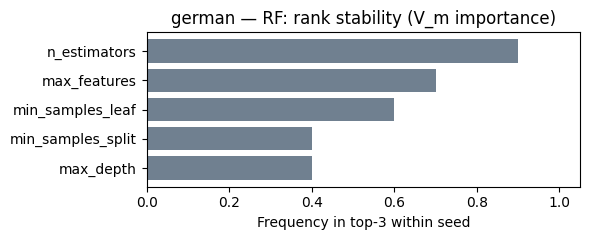

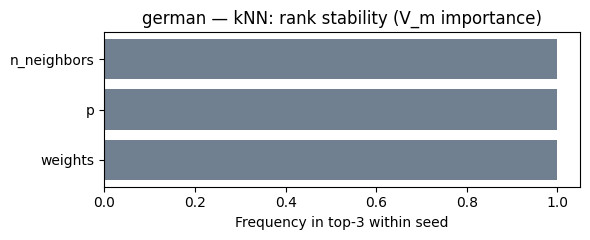

In [22]:
_vm_rank = df_vm_agg.copy()
if not _vm_rank.empty and "pool_type" in _vm_rank.columns:
    _vm_rank = _vm_rank[_vm_rank["pool_type"] == POOL_TYPE_RASHOMON]
if not _vm_rank.empty:
    for (ds, fam), grp in _vm_rank.groupby(["dataset", "family"]):
        top = grp.nlargest(TOP_HP, "mean_importance")
        fig, ax = plt.subplots(figsize=(6, max(2.5, 0.35 * len(top))))
        y = np.arange(len(top))
        ax.barh(y, top["rank_freq_top3"], color="slategray")
        ax.set_yticks(y)
        ax.set_yticklabels(top["hp_name"])
        ax.invert_yaxis()
        ax.set_xlim(0, 1.05)
        ax.set_xlabel("Frequency in top-3 within seed")
        ax.set_title(f"{ds} — {fam}: rank stability (V_m importance)")
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"hp_rank_stability_{ds}_{fam}.pdf", bbox_inches="tight")
        plt.show()


## Decomposition-based within-family HP (subset = all)


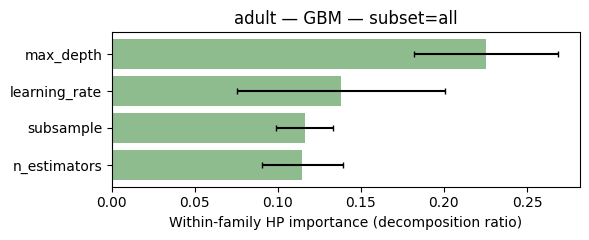

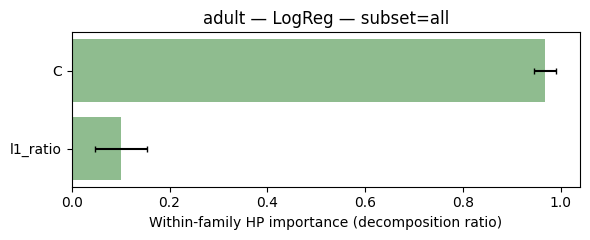

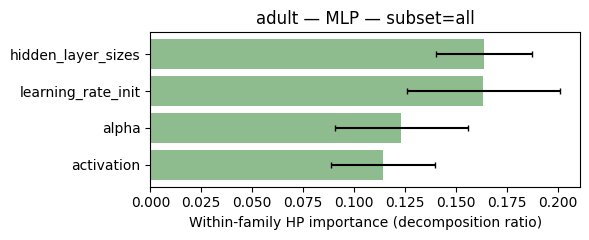

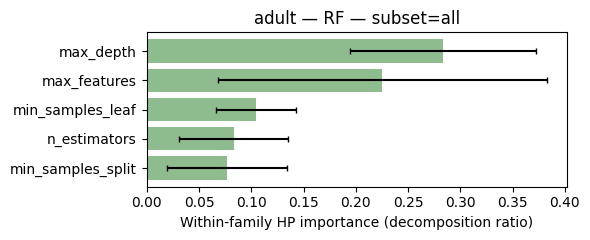

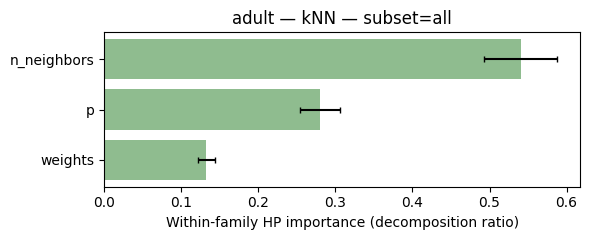

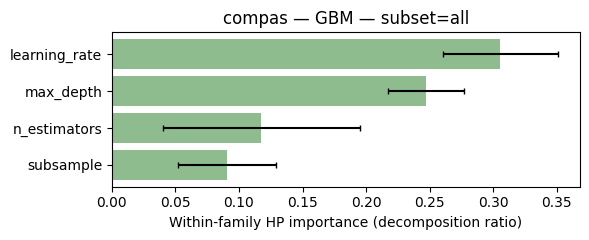

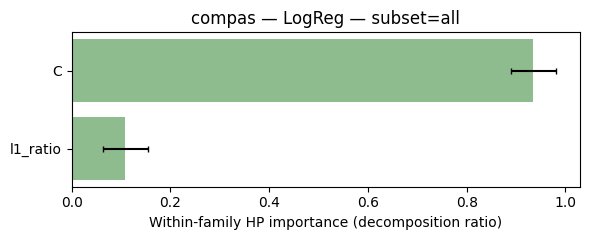

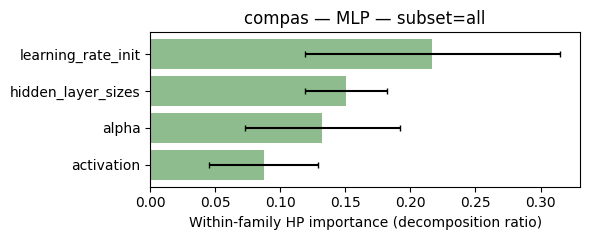

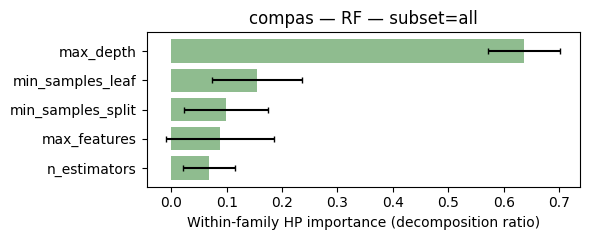

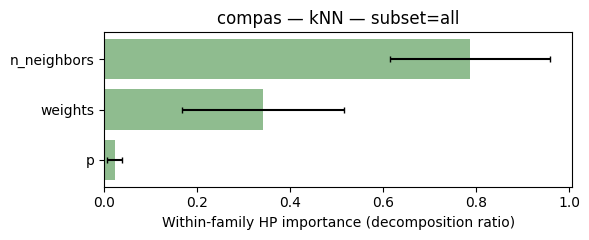

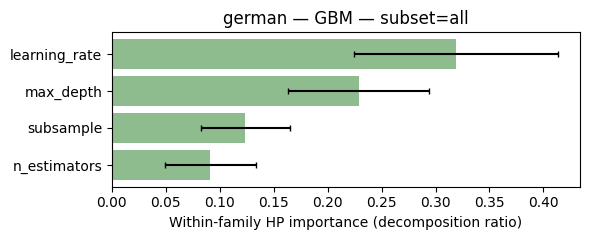

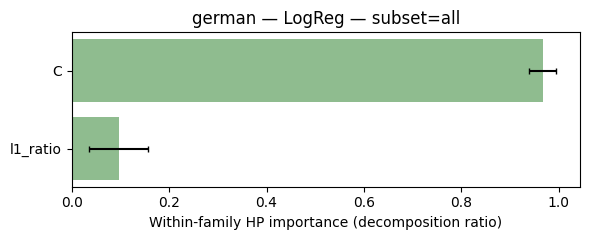

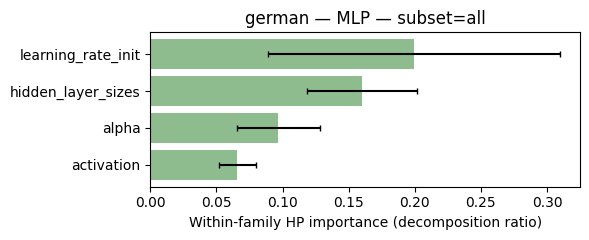

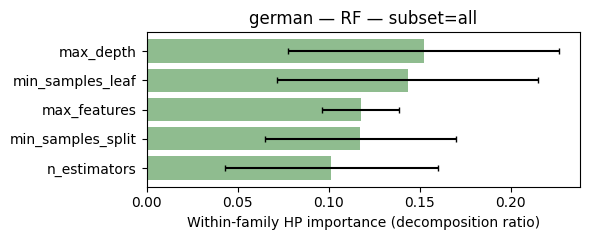

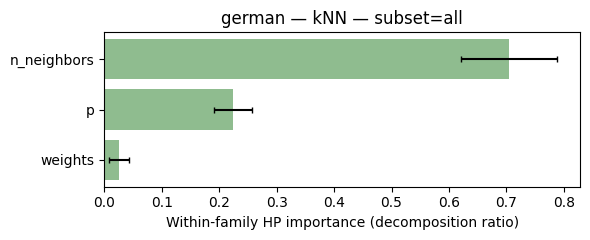

In [23]:
decomp_all = pd.DataFrame()
if not df_decomp_agg.empty:
    decomp_all = df_decomp_agg[df_decomp_agg["subset"] == "all"].copy()
    if "pool_type" in decomp_all.columns:
        decomp_all = decomp_all[decomp_all["pool_type"] == POOL_TYPE_RASHOMON]
if not decomp_all.empty:
    for (ds, fam), _ in decomp_all.groupby(["dataset", "family"]):
        plot_decomp_hp_bars(
            decomp_all,
            dataset=ds,
            subset="all",
            family=fam,
            top_n=TOP_HP,
            fig_path=FIG_DIR / f"decomp_hp_importance_bar_{ds}_{fam}.pdf",
        )
else:
    print("No decomposition HP aggregates.")


## Hotspot vs all (decomposition HP delta)


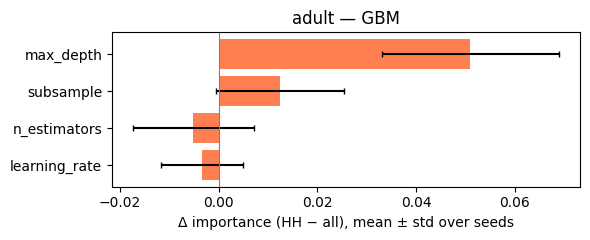

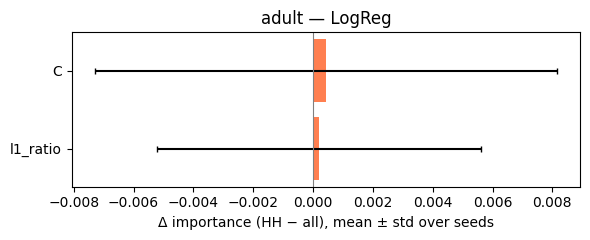

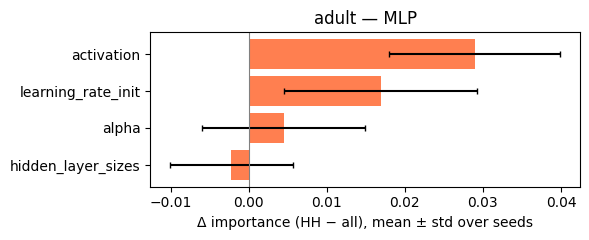

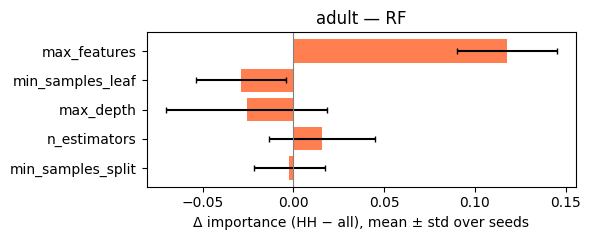

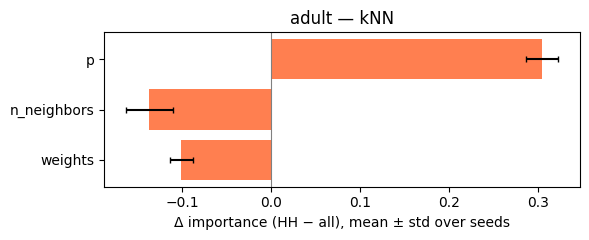

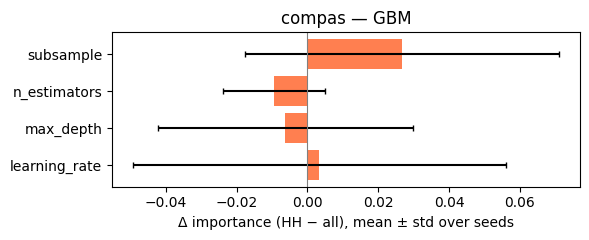

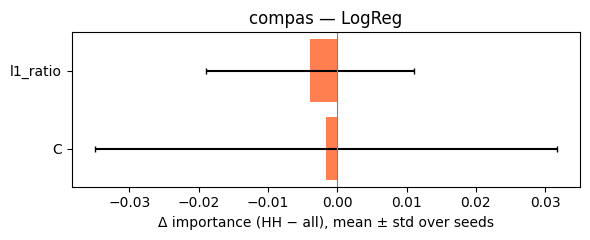

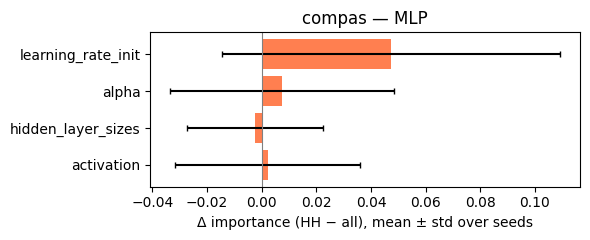

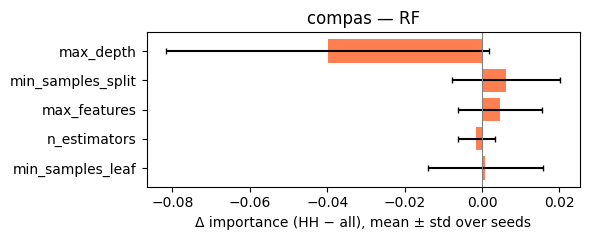

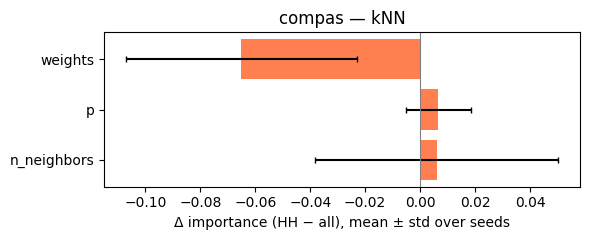

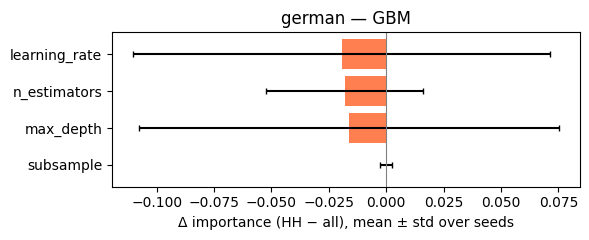

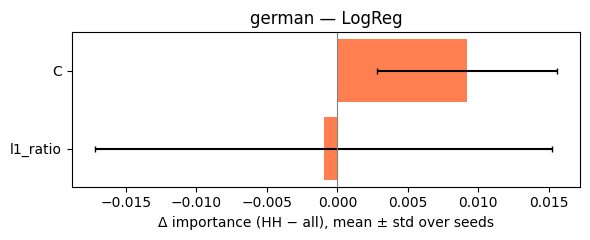

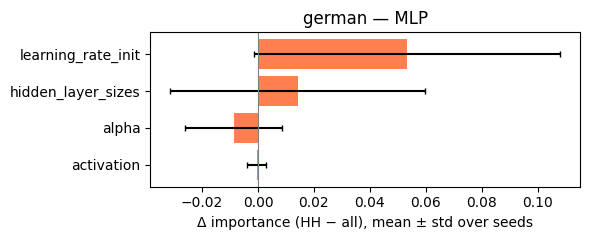

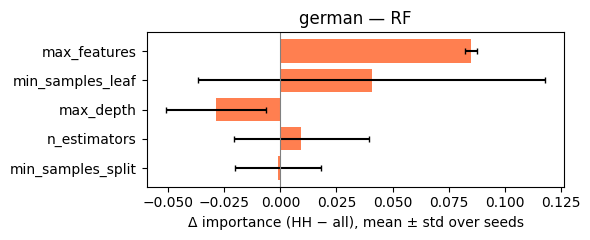

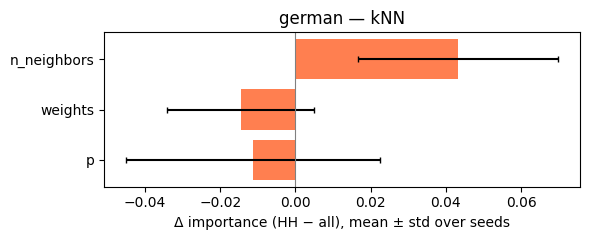

In [24]:
_ddel = df_delta_agg.copy()
if not _ddel.empty and "pool_type" in _ddel.columns:
    _ddel = _ddel[_ddel["pool_type"] == POOL_TYPE_RASHOMON]
if not _ddel.empty:
    for (ds, fam), _ in _ddel.groupby(["dataset", "family"]):
        plot_hotspot_hp_delta(
            _ddel,
            dataset=ds,
            family=fam,
            top_n=TOP_HP,
            fig_path=FIG_DIR / f"decomp_hp_hotspot_delta_{ds}_{fam}.pdf",
        )
else:
    print("No hotspot deltas (need HH subset with enough points per seed).")


## Compact summary tables (top HPs per family)


In [25]:
cols_show = [
    c
    for c in [
        "dataset",
        "pool_type",
        "subset",
        "family",
        "hp_name",
        "mean_importance",
        "std_importance",
        "mean_rank",
        "rank_freq_top1",
        "rank_freq_top3",
        "n_seeds",
    ]
    if c in df_vm_agg.columns
]
_vm_sum = df_vm_agg.copy()
if not _vm_sum.empty and "pool_type" in _vm_sum.columns:
    _vm_sum = _vm_sum[_vm_sum["pool_type"] == POOL_TYPE_RASHOMON]
if not _vm_sum.empty:
    for (ds, fam), grp in _vm_sum.groupby(["dataset", "family"]):
        top = grp.sort_values("mean_importance", ascending=False).head(5)[cols_show]
        print(f"\n{ds} | {fam} | V_m-based (subset=all)\n", top.to_string(index=False))
        top.to_csv(TABLE_DIR / f"hp_top5_summary_{ds}_{fam}.csv", index=False)

cols_d = [c for c in ["dataset", "pool_type", "subset", "family", "hp", "mean_importance", "std_importance", "mean_rank", "rank_freq_top1", "rank_freq_top3", "n_seeds"] if c in decomp_all.columns]
if not decomp_all.empty:
    for (ds, fam), grp in decomp_all.groupby(["dataset", "family"]):
        top = grp.sort_values("mean_importance", ascending=False).head(5)[cols_d]
        print(f"\n{ds} | {fam} | decomposition (subset=all)\n", top.to_string(index=False))



adult | GBM | V_m-based (subset=all)
 dataset pool_type subset family       hp_name  mean_importance  std_importance  mean_rank  rank_freq_top1  rank_freq_top3  n_seeds
  adult  Rashomon    all    GBM learning_rate         0.246709        0.086559        1.3             0.7             1.0       10
  adult  Rashomon    all    GBM     max_depth         0.116870        0.091055        2.5             0.1             0.9       10
  adult  Rashomon    all    GBM  n_estimators         0.112527        0.096963        2.7             0.2             0.7       10
  adult  Rashomon    all    GBM     subsample         0.043683        0.048021        3.5             0.0             0.4       10

adult | LogReg | V_m-based (subset=all)
 dataset pool_type subset family  hp_name  mean_importance  std_importance  mean_rank  rank_freq_top1  rank_freq_top3  n_seeds
  adult  Rashomon    all LogReg        C         0.921326        0.069895        1.0             1.0             1.0       10
  adult  Ras

## Marginal V_m for top HP (subset = all)


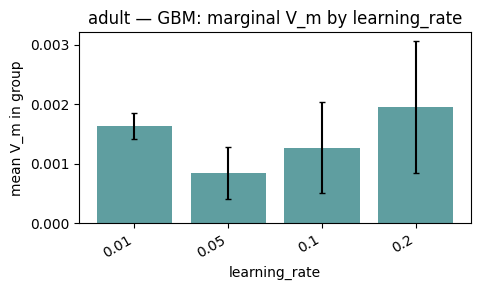

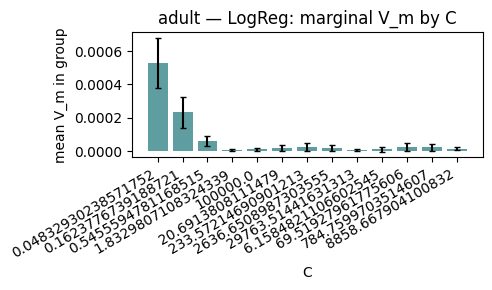

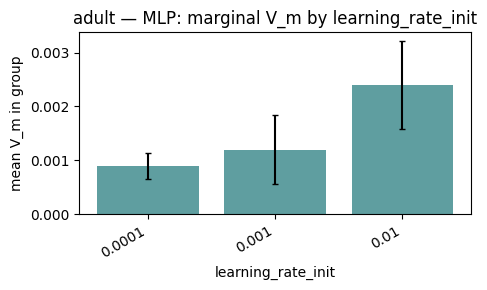

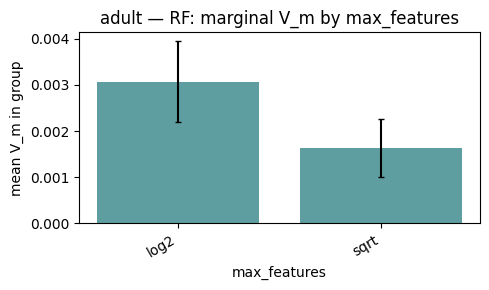

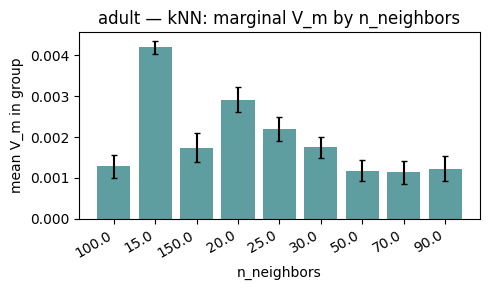

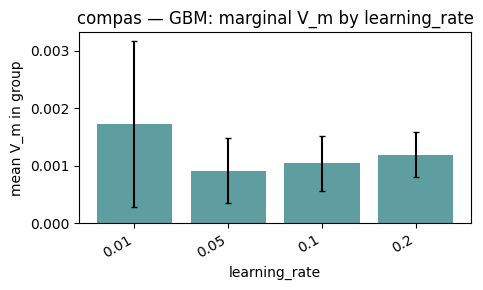

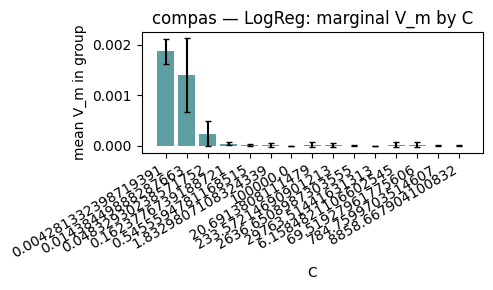

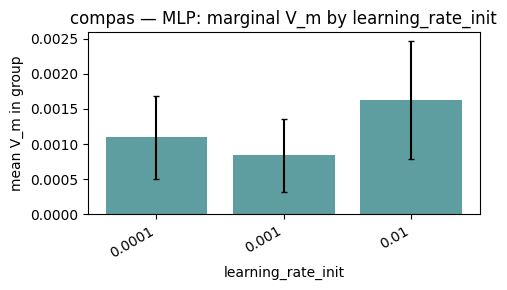

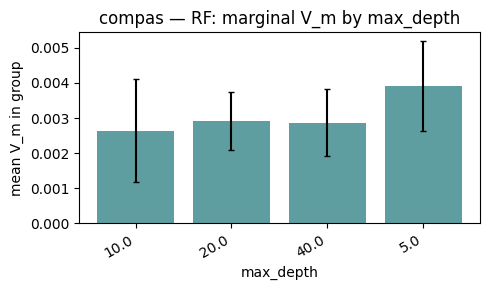

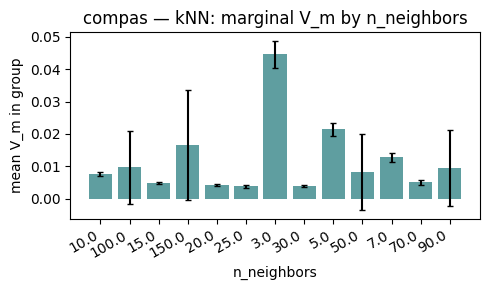

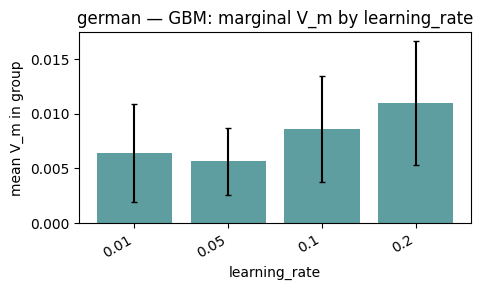

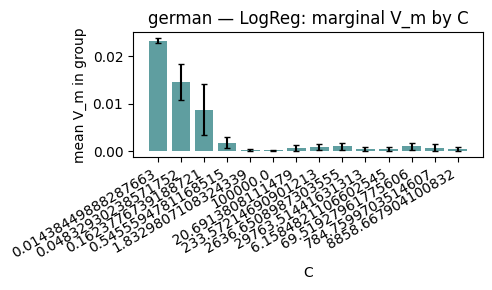

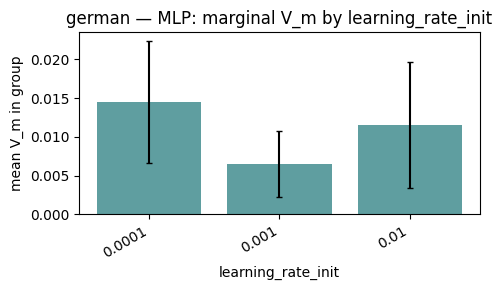

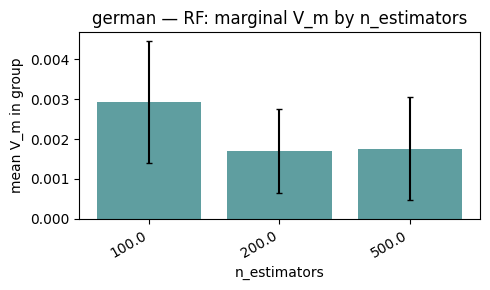

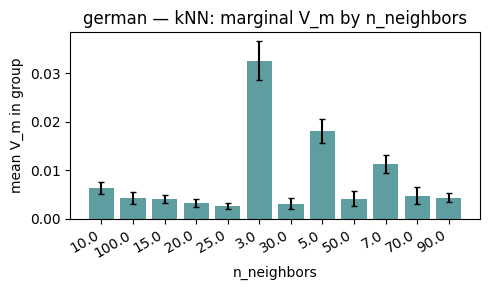

In [26]:
_vm_marg = df_vm_agg.copy()
if not _vm_marg.empty and "pool_type" in _vm_marg.columns:
    _vm_marg = _vm_marg[_vm_marg["pool_type"] == POOL_TYPE_RASHOMON]
if not _vm_marg.empty and not df_models.empty:
    for (ds, fam), grp in _vm_marg.groupby(["dataset", "family"]):
        top_hp = grp.sort_values("mean_importance", ascending=False).head(1)
        if top_hp.empty:
            continue
        hp_name = top_hp["hp_name"].iloc[0]
        col = f"hp_{hp_name}"
        mm = df_models[(df_models["dataset"] == ds) & (df_models["family"] == fam)]
        if "pool_type" in mm.columns:
            mm = mm[mm["pool_type"] == POOL_TYPE_RASHOMON]
        if col not in mm.columns:
            continue
        marg = marginal_Vm_by_hp(mm["V_m"].values, mm, col)
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.bar(
            [str(x) for x in marg["hp_value"]],
            marg["mean_Vm"],
            yerr=marg["std_Vm"],
            capsize=2,
            color="cadetblue",
        )
        ax.set_xlabel(hp_name)
        ax.set_ylabel("mean V_m in group")
        ax.set_title(f"{ds} — {fam}: marginal V_m by {hp_name}")
        fig.autofmt_xdate()
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"hp_marginal_effect_{ds}_{fam}_{hp_name}.pdf", bbox_inches="tight")
        plt.show()


## Diagnostic: pool size and V_m run coverage


In [27]:
if not df_vm_hp.empty:
    diag = (
        df_vm_hp.groupby(["dataset", "family", "pool_type", "subset"])["K_actual"]
        .agg(min_K="min", max_K="max", mean_K="mean")
        .reset_index()
    )
    display(diag)
else:
    print("No V_m HP table.")


,dataset,family,pool_type,subset,min_K,max_K,mean_K
0,adult,GBM,Rashomon,HH,25,25,25.0
1,adult,GBM,Rashomon,all,25,25,25.0
2,adult,GBM,Rashomon,non_HH,25,25,25.0
3,adult,LogReg,Rashomon,HH,25,25,25.0
4,adult,LogReg,Rashomon,all,25,25,25.0
5,adult,LogReg,Rashomon,non_HH,25,25,25.0
6,adult,MLP,Rashomon,HH,25,25,25.0
7,adult,MLP,Rashomon,all,25,25,25.0
8,adult,MLP,Rashomon,non_HH,25,25,25.0
9,adult,RF,Rashomon,HH,25,25,25.0


## Hyperparameter diversity (Rashomon pool)


In [28]:
from analysis.hyperparams import compute_hp_diversity, compute_hp_entropy, compute_prediction_difference_by_hp
from analysis.run_analysis import load_meta, load_P_test

div_rows = []
for ds in DATASETS:
    ds_dir = RESULTS_DIR / ds
    if not ds_dir.is_dir():
        continue
    for run_dir in sorted(
        [p for p in ds_dir.iterdir() if p.is_dir() and p.name.startswith("seed=")],
        key=lambda p: int(p.name.split("=")[1]),
    ):
        meta = load_meta(run_dir)
        P_test = load_P_test(run_dir)
        idx = select_pool_indices(run_dir, pool_type=POOL_TYPE_RASHOMON, rashomon_k_each=K_EACH)
        meta_sel = meta.iloc[idx].reset_index(drop=True)
        P_sel = P_test[idx]
        div_df = compute_hp_diversity(meta_sel)
        ent_df = compute_hp_entropy(meta_sel)
        pred_df = compute_prediction_difference_by_hp(meta_sel, P_sel)
        div_rows.append(
            {
                "dataset": ds,
                "seed": int(run_dir.name.split("=")[1]),
                "mean_distinct": float(div_df["n_distinct_values"].mean()) if not div_df.empty else float("nan"),
                "mean_entropy": float(ent_df["normalized_entropy"].mean()) if not ent_df.empty else float("nan"),
                "mean_pred_diff": float(pred_df["mean_diff_different_hp"].mean()) if not pred_df.empty else float("nan"),
            }
        )

if div_rows:
    div_summary = pd.DataFrame(div_rows).groupby("dataset").agg(["mean", "std"])
    display(div_summary)
else:
    print("No diversity summary.")


seed          mean_distinct           mean_entropy           mean_pred_diff          
        mean      std          mean       std         mean       std           mean       std
dataset                                                                                      
adult    4.5  3.02765      0.668333  0.012910     0.607446  0.011535       0.030109  0.001025
compas   4.5  3.02765      0.709167  0.007297     0.581315  0.009884       0.052276  0.004743
german   4.5  3.02765      0.679167  0.012577     0.610230  0.009143       0.072999  0.003263

## Minimal full-pool vs Rashomon (optional)


In [29]:
# Set RUN_FULL_POOL_COMPARE = True to also run the full candidate pool and compare global family ratio (subset=all).
RUN_FULL_POOL_COMPARE = False

if RUN_FULL_POOL_COMPARE and POOL_TYPE_FULL_POOL not in POOL_TYPES:
    cmp_rows = []
    for ds in DATASETS:
        ds_dir = RESULTS_DIR / ds
        if not ds_dir.is_dir() or not _get_run_dirs(ds_dir):
            continue
        full = run_dataset_all_seeds(ds_dir, ds, pool_type=POOL_TYPE_FULL_POOL, rashomon_k_each=K_EACH)
        rash = run_dataset_all_seeds(ds_dir, ds, pool_type=POOL_TYPE_RASHOMON, rashomon_k_each=K_EACH)
        fa = aggregate_family_importance_long(full["metrics_long"])
        ra = aggregate_family_importance_long(rash["metrics_long"])
        fa_s = fa[(fa["dataset"] == ds) & (fa["subset"] == "all")].assign(label="full_pool")
        ra_s = ra[(ra["dataset"] == ds) & (ra["subset"] == "all")].assign(label="Rashomon")
        cmp_rows.append(pd.concat([fa_s, ra_s], ignore_index=True))
    if cmp_rows:
        cmp_df = pd.concat(cmp_rows, ignore_index=True)
        display(cmp_df)
        cmp_df.to_csv(TABLE_DIR / "family_importance_full_vs_rashomon.csv", index=False)


## Summary


In [30]:
_vm_fin = df_vm_agg.copy()
if not _vm_fin.empty and "pool_type" in _vm_fin.columns:
    _vm_fin = _vm_fin[_vm_fin["pool_type"] == POOL_TYPE_RASHOMON]
if not _vm_fin.empty:
    print("Top-3 V_m-based HPs per (dataset, family), subset=all:\n")
    for (ds, fam), grp in _vm_fin.groupby(["dataset", "family"]):
        top3 = grp.head(3)
        items = ", ".join(
            f"{r.hp_name} ({r.mean_importance:.3f} ± {r.std_importance:.3f})"
            for _, r in top3.iterrows()
        )
        print(f"  {ds} | {fam}: {items}")


Top-3 V_m-based HPs per (dataset, family), subset=all:

  adult | GBM: learning_rate (0.247 ± 0.087), max_depth (0.117 ± 0.091), n_estimators (0.113 ± 0.097)
  adult | LogReg: C (0.921 ± 0.070), l1_ratio (0.112 ± 0.059)
  adult | MLP: learning_rate_init (0.513 ± 0.180), hidden_layer_sizes (0.159 ± 0.116), alpha (0.138 ± 0.142)
  adult | RF: max_features (0.669 ± 0.111), max_depth (0.113 ± 0.093), min_samples_leaf (0.107 ± 0.053)
  adult | kNN: n_neighbors (0.868 ± 0.040), weights (0.113 ± 0.042), p (0.021 ± 0.019)
  compas | GBM: learning_rate (0.151 ± 0.125), max_depth (0.141 ± 0.061), n_estimators (0.128 ± 0.096)
  compas | LogReg: C (0.862 ± 0.121), l1_ratio (0.107 ± 0.039)
  compas | MLP: learning_rate_init (0.266 ± 0.122), hidden_layer_sizes (0.181 ± 0.078), alpha (0.159 ± 0.130)
  compas | RF: max_depth (0.333 ± 0.212), min_samples_leaf (0.113 ± 0.107), min_samples_split (0.108 ± 0.101)
  compas | kNN: n_neighbors (0.733 ± 0.272), weights (0.627 ± 0.271), p (0.025 ± 0.031)
  germ